# Lab 3: Attention-based NMT

In [67]:
import math
import random
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## Implement Attention

In [68]:
class DotAttention(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, query, keys, mask=None):
        """
        query: [batch, hidden]
        keys: [batch, src_len, hidden]
        mask: [batch, src_len], 1 for valid token, 0 for pad
        """
        scores = torch.bmm(keys, query.unsqueeze(2)).squeeze(2)  # [B, S]

        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)

        attn_weights = F.softmax(scores, dim=1)  # [B, S]
        context = torch.bmm(attn_weights.unsqueeze(1), keys).squeeze(1)  # [B, H]
        return context, attn_weights

## Data Preparation
Build vocabularies, convert sentence pairs to ids, and create DataLoaders.

In [69]:
PAD_TOKEN = "<pad>"
SOS_TOKEN = "<sos>"
EOS_TOKEN = "<eos>"
UNK_TOKEN = "<unk>"
SPECIAL_TOKENS = [PAD_TOKEN, SOS_TOKEN, EOS_TOKEN, UNK_TOKEN]

def read_lines(path):
    with open(path, "r", encoding="utf-8") as f:
        return [line.strip() for line in f if line.strip()]

def tokenize(sentence):
    return sentence.split()

def build_vocab(sentences, min_freq=1):
    counter = Counter()
    for s in sentences:
        counter.update(tokenize(s))

    itos = SPECIAL_TOKENS.copy()
    for token, freq in counter.items():
        if freq >= min_freq and token not in itos:
            itos.append(token)
    stoi = {tok: idx for idx, tok in enumerate(itos)}
    return stoi, itos

def encode(sentence, stoi):
    tokens = tokenize(sentence)
    ids = [stoi.get(SOS_TOKEN)]
    ids += [stoi.get(tok, stoi[UNK_TOKEN]) for tok in tokens]
    ids += [stoi.get(EOS_TOKEN)]
    return ids

class TranslationDataset(Dataset):
    def __init__(self, src_lines, tgt_lines, src_stoi, tgt_stoi):
        assert len(src_lines) == len(tgt_lines), "Source/target size mismatch"
        self.pairs = list(zip(src_lines, tgt_lines))
        self.src_stoi = src_stoi
        self.tgt_stoi = tgt_stoi

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        src, tgt = self.pairs[idx]
        src_ids = torch.tensor(encode(src, self.src_stoi), dtype=torch.long)
        tgt_ids = torch.tensor(encode(tgt, self.tgt_stoi), dtype=torch.long)
        return src_ids, tgt_ids

def make_collate_fn(src_pad_id, tgt_pad_id):
    def collate(batch):
        src_batch, tgt_batch = zip(*batch)
        src_batch = nn.utils.rnn.pad_sequence(src_batch, batch_first=True, padding_value=src_pad_id)
        tgt_batch = nn.utils.rnn.pad_sequence(tgt_batch, batch_first=True, padding_value=tgt_pad_id)
        src_mask = (src_batch != src_pad_id).long()
        return src_batch, tgt_batch, src_mask
    return collate

data_dir = Path("data")
train_en = read_lines(data_dir / "train.en")
train_vi = read_lines(data_dir / "train.vi")
dev_en = read_lines(data_dir / "dev.en")
dev_vi = read_lines(data_dir / "dev.vi")

# Keep training light enough for notebook execution speed.
max_train = min(8000, len(train_en))
train_en = train_en[:max_train]
train_vi = train_vi[:max_train]

src_stoi, src_itos = build_vocab(train_en)
tgt_stoi, tgt_itos = build_vocab(train_vi)

src_pad_id = src_stoi[PAD_TOKEN]
tgt_pad_id = tgt_stoi[PAD_TOKEN]
tgt_sos_id = tgt_stoi[SOS_TOKEN]
tgt_eos_id = tgt_stoi[EOS_TOKEN]

train_ds = TranslationDataset(train_en, train_vi, src_stoi, tgt_stoi)
dev_ds = TranslationDataset(dev_en, dev_vi, src_stoi, tgt_stoi)

collate_fn = make_collate_fn(src_pad_id, tgt_pad_id)
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, collate_fn=collate_fn)
dev_loader = DataLoader(dev_ds, batch_size=64, shuffle=False, collate_fn=collate_fn)

print(f"Train pairs: {len(train_ds)}, Dev pairs: {len(dev_ds)}")
print(f"Source vocab size: {len(src_itos)}, Target vocab size: {len(tgt_itos)}")

Train pairs: 10, Dev pairs: 3
Source vocab size: 35, Target vocab size: 44


## Attention-based Seq2Seq Model
Encoder creates hidden states; decoder attends to encoder outputs at every step.

In [70]:
class Encoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim, pad_id):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=pad_id)
        self.gru = nn.GRU(emb_dim, hidden_dim, batch_first=True)

    def forward(self, src):
        emb = self.embedding(src)                        # [B, S, E]
        outputs, hidden = self.gru(emb)                  # outputs: [B, S, H], hidden: [1, B, H]
        return outputs, hidden

class AttnDecoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim, pad_id):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=pad_id)
        self.attn = DotAttention()
        self.gru = nn.GRU(emb_dim + hidden_dim, hidden_dim, batch_first=True)
        self.proj = nn.Linear(hidden_dim * 2, vocab_size)

    def forward(self, input_token, hidden, encoder_outputs, src_mask):
        # input_token: [B], hidden: [1, B, H]
        emb = self.embedding(input_token).unsqueeze(1)   # [B, 1, E]
        query = hidden[-1]                               # [B, H]

        context, attn_weights = self.attn(query, encoder_outputs, src_mask)
        rnn_in = torch.cat([emb, context.unsqueeze(1)], dim=-1)  # [B, 1, E+H]
        out, hidden = self.gru(rnn_in, hidden)           # out: [B, 1, H]

        logits = self.proj(torch.cat([out.squeeze(1), context], dim=-1))  # [B, V]
        return logits, hidden, attn_weights

class Seq2SeqAttention(nn.Module):
    def __init__(self, encoder, decoder, tgt_sos_id):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.tgt_sos_id = tgt_sos_id

    def forward(self, src, tgt, src_mask, teacher_forcing_ratio=0.5):
        # src: [B, S], tgt: [B, T]
        batch_size, tgt_len = tgt.size()
        vocab_size = self.decoder.proj.out_features

        encoder_outputs, hidden = self.encoder(src)
        outputs = torch.zeros(batch_size, tgt_len - 1, vocab_size, device=src.device)
        all_attn = []

        input_token = tgt[:, 0]  # <sos>
        for t in range(1, tgt_len):
            logits, hidden, attn_weights = self.decoder(
                input_token, hidden, encoder_outputs, src_mask
            )
            outputs[:, t - 1] = logits
            all_attn.append(attn_weights)

            teacher_force = random.random() < teacher_forcing_ratio
            top1 = logits.argmax(dim=-1)
            input_token = tgt[:, t] if teacher_force else top1

        # [B, T-1, S]
        all_attn = torch.stack(all_attn, dim=1) if all_attn else None
        return outputs, all_attn

## Training and Evaluation

In [75]:
def compute_loss(logits, targets, pad_id):
    # logits: [B, T-1, V], targets: [B, T]
    logits = logits.reshape(-1, logits.size(-1))
    targets = targets[:, 1:].reshape(-1)
    return F.cross_entropy(logits, targets, ignore_index=pad_id)

def run_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    for src, tgt, src_mask in loader:
        src = src.to(device)
        tgt = tgt.to(device)
        src_mask = src_mask.to(device)

        with torch.set_grad_enabled(is_train):
            logits, _ = model(
                src, tgt, src_mask,
                teacher_forcing_ratio=0.5 if is_train else 0.0
            )
            loss = compute_loss(logits, tgt, tgt_pad_id)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

        total_loss += loss.item()
    return total_loss / max(1, len(loader))

emb_dim = 128
hidden_dim = 256

encoder = Encoder(len(src_itos), emb_dim, hidden_dim, src_pad_id).to(device)
decoder = AttnDecoder(len(tgt_itos), emb_dim, hidden_dim, tgt_pad_id).to(device)
model = Seq2SeqAttention(encoder, decoder, tgt_sos_id).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

num_epochs = 30
for epoch in range(1, num_epochs + 1):
    train_loss = run_epoch(model, train_loader, optimizer=optimizer)
    dev_loss = run_epoch(model, dev_loader, optimizer=None)
    print(f"Epoch {epoch:02d} | train loss: {train_loss:.4f} | dev loss: {dev_loss:.4f}")

Epoch 01 | train loss: 3.7868 | dev loss: 3.6725
Epoch 02 | train loss: 3.6301 | dev loss: 3.4549
Epoch 03 | train loss: 3.4397 | dev loss: 3.2563
Epoch 04 | train loss: 3.3009 | dev loss: 3.0658
Epoch 05 | train loss: 3.1337 | dev loss: 2.8936
Epoch 06 | train loss: 2.9516 | dev loss: 2.7230
Epoch 07 | train loss: 2.7466 | dev loss: 2.5228
Epoch 08 | train loss: 2.6249 | dev loss: 2.3626
Epoch 09 | train loss: 2.3182 | dev loss: 2.2646
Epoch 10 | train loss: 2.2139 | dev loss: 2.1175
Epoch 11 | train loss: 2.0736 | dev loss: 1.9552
Epoch 12 | train loss: 1.8297 | dev loss: 1.8413
Epoch 13 | train loss: 1.7101 | dev loss: 1.5373
Epoch 14 | train loss: 1.5569 | dev loss: 1.3850
Epoch 15 | train loss: 1.3607 | dev loss: 1.2240
Epoch 16 | train loss: 1.2187 | dev loss: 1.0828
Epoch 17 | train loss: 1.0766 | dev loss: 0.9381
Epoch 18 | train loss: 0.9512 | dev loss: 0.8143
Epoch 19 | train loss: 0.8581 | dev loss: 0.7130
Epoch 20 | train loss: 0.7562 | dev loss: 0.6232
Epoch 21 | train los

## Translate test

In [76]:
# Quick test after training
test_loss = run_epoch(model, dev_loader, optimizer=None)
test_ppl = math.exp(min(test_loss, 20))
print(f"Test (dev) loss: {test_loss:.4f}")
print(f"Test (dev) perplexity: {test_ppl:.2f}")

Test (dev) loss: 0.1254
Test (dev) perplexity: 1.13


## Inference and Attention Heatmap

Source: i am a teacher
Reference: tôi là giáo viên
Prediction: tôi là giáo viên


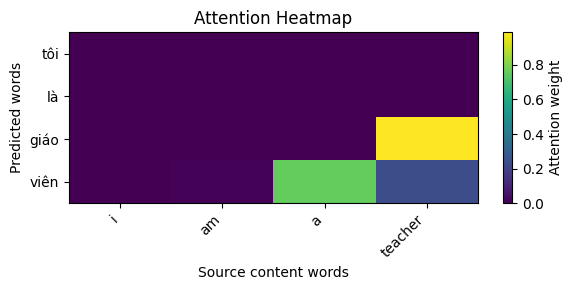

In [80]:
# Simple attention visualization: focus on content words only.
sample_idx = 0
src_sentence = dev_en[sample_idx]
ref_sentence = dev_vi[sample_idx]

src_tokens = [SOS_TOKEN] + tokenize(src_sentence) + [EOS_TOKEN]
src_ids = [src_stoi.get(tok, src_stoi[UNK_TOKEN]) for tok in src_tokens]
src = torch.tensor(src_ids, dtype=torch.long, device=device).unsqueeze(0)
src_mask = (src != src_stoi[PAD_TOKEN]).long()

model.eval()
with torch.no_grad():
    enc_out, hidden = model.encoder(src)
    inp = torch.tensor([tgt_sos_id], dtype=torch.long, device=device)
    pred_tokens, attn_rows = [], []
    for _ in range(60):
        logits, hidden, attn_w = model.decoder(inp, hidden, enc_out, src_mask)
        next_id = int(logits.argmax(dim=-1).item())
        if next_id == tgt_eos_id:
            break
        pred_tokens.append(tgt_itos[next_id])
        attn_rows.append(attn_w.squeeze(0).cpu())
        inp = torch.tensor([next_id], dtype=torch.long, device=device)

print("Source:", src_sentence)
print("Reference:", ref_sentence)
print("Prediction:", " ".join(pred_tokens))

if attn_rows:
    attn = torch.stack(attn_rows).numpy()  # [tgt_len, src_len]
    keep_cols = [i for i, tok in enumerate(src_tokens) if tok not in (SOS_TOKEN, EOS_TOKEN, PAD_TOKEN)]
    attn = attn[:, keep_cols]
    src_plot_tokens = [src_tokens[i] for i in keep_cols]

    plt.figure(figsize=(max(6, 0.6 * len(src_plot_tokens)), max(3, 0.5 * len(pred_tokens))))
    plt.imshow(attn, aspect="auto", cmap="viridis")
    plt.xticks(range(len(src_plot_tokens)), src_plot_tokens, rotation=45, ha="right")
    plt.yticks(range(len(pred_tokens)), pred_tokens)
    plt.xlabel("Source content words")
    plt.ylabel("Predicted words")
    plt.title("Attention Heatmap")
    plt.colorbar(label="Attention weight")
    plt.tight_layout()
    plt.show()
else:
    print("Model did not generate tokens for this sample.")